<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Patricia González Todd

En este trabajo buscamos simular la función de un ADC de B bits en . Dicho ADC tiene como entrada una senoidal que contiene un ruido de caracter aditivo, incorrelado y distribución gaussiana, tendrá como salida una señal cuantizada con un paso de cuantización q, junto a esto se sumará un error de cuantización que viene dado por el error de redondeo al asignar cada muestra en su nivel más cercano.
Al terminar el proseso se analizará la señal de entrada como una señal analógica con ruido agregado debido a ruido térmico y la señal de salida como  una señal digital con un error  debido  al ruido de la señal de entrada más el error de cuantización. Este análisis se reali

 var = 1.0000000000000002


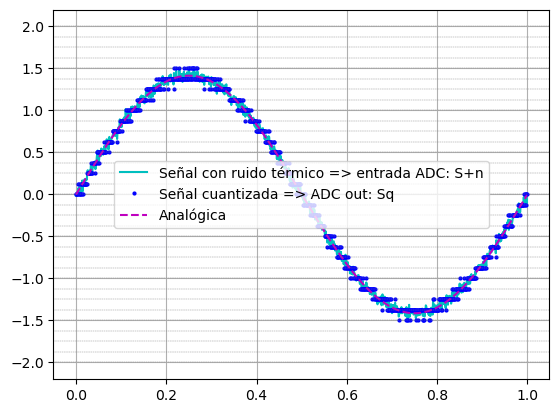

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def mi_funcion_ruido (tt, Pr):
    desvio = np.sqrt(Pr)
    r = np.random.normal(0, desvio, len(tt)) # lo del medio es el desvio estandar
    #verifico el valor de la varianza de r a ver si calcule bien
    return r

# Parámetros
A = np.sqrt(2)
dc = 0
fs = 1000
fase = 0
muestras = 1000
f0 = fs/muestras #delta f que es RESOLUCION ESPECTRAL
bits = 4
# 4 bits => 16 niveles
Vf = 2
q = Vf/(2**(bits))
Ps = (A**2)/ 2 
Pq = (q**2)/12 #para ruido de cuantización uniforme
kn = 1
Pn = kn * Pq #ESTO DEBERIA SER LA VARIANZA
SNR = Ps/Pn
SNR_db = 10*np.log10(SNR + 1e-15)


# Llamadas a las funciones
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)
n = mi_funcion_ruido(tt, Pn)
print(f" var = {np.var(S)}")
Sn = S + n

# recorte al rango del ADC
Sn_clip = np.clip(Sn, -Vf, Vf)

#Cuantizacion
Sq = q* np.round(Sn_clip/q)

#Error de cuantizacion
Error_q = Sq - Sn

#Grafico
plt.plot(tt, Sn,'c' , label="Señal con ruido térmico => entrada ADC: S+n")
plt.plot(tt, Sq, 'o', color='b', markersize=2, label = "Señal cuantizada => ADC out: Sq")
plt.plot(tt, S,'m--', label="Analógica")
for nivel in niveles:
    plt.axhline(nivel, color='gray', linestyle='--', linewidth=0.3)

plt.legend()
plt.grid()
plt.show()

Se Puede evidenciar que la señal Sq consta de muestras contenidas en niveles específicos dados por los múltiplos de q en el rango dado, de esta manera se afirma que la salida de un ADC es una señal cuantizada, que significa discretizada en tiempo y en voltaje.

Con el histograma de el error de cuantizaciòn demostramos la hipotesis (y objetivo) de una distribuciòon uniforme de ruido blanco contenido en un rango de [q/2; +q/2] 

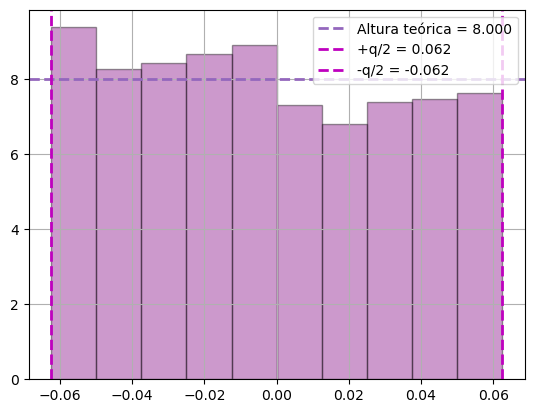

In [102]:
#%% Histograma del error de cuantizacion
plt.hist(Error_q, bins=10, density=True, color='purple', alpha=0.4,
         edgecolor='black')

plt.axhline(1/q, color='C4',
            label=f"Altura teórica = {1/q:.3f}",
            linestyle='--', linewidth=2)

# Límites teóricos del error de cuantización
plt.axvline(q/2, color='m',
            label=f"+q/2 = {q/2:.3f}",
            linestyle='--', linewidth=2)

plt.axvline(-q/2, color='m',
            label=f"-q/2 = {-q/2:.3f}",
            linestyle='--', linewidth=2)

plt.grid(True)
plt.legend()
plt.show()

Ahora pasamos a analizar el espectro en frecuencias, en este gráfico queremos evidenciar la densidad esppecttral de la potencia en decibeles, esto permite comparar el piso de ruido de la señal.

 T vs M -58.85361219697974 ~ -58.48887702091206 analogicos
 T vs M -55.84331224200761 ~ -55.8002505260847 digital
 Diferencia de pisos = 10log10((Pq+ Pn)/muestras) - 10log10(Pn/muestras) = 10log10( 2Pq/Pq) = 10* 0.3010299956639812= 3.010299954972126 


Text(0, 0.5, 'Amplitud')

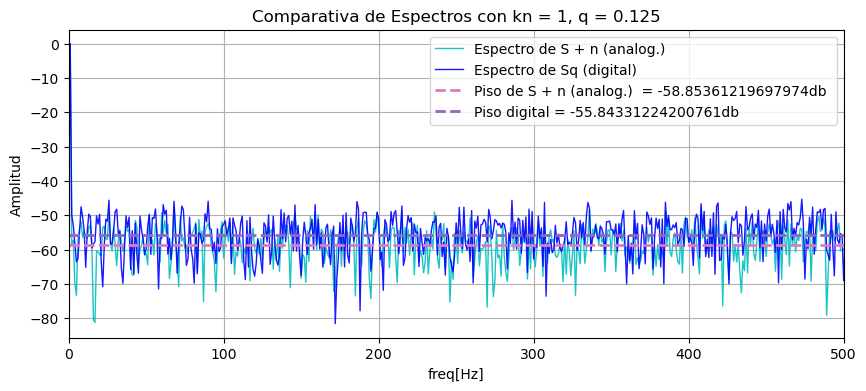

In [103]:
#espectros escalados para normalizar la señal en V y llevarla a 0dB
#Sr
e_Sr = np.fft.fft(Sn)/(muestras)  
mod_e_Sr = 2* np.abs((e_Sr))**2
#Sq
e_Sq = np.fft.fft(Sq)/(muestras)
mod_e_Sq =2* np.abs((e_Sq))**2

# paso a db
mod_e_Sr_db = 10*np.log10(mod_e_Sr + 1e-15) #db
mod_e_Sq_db = 10*np.log10(mod_e_Sq + 1e-15) #db 

#pisos => BUSCAR EL ESTIMADO TEORICO
piso_analog = np.mean(mod_e_Sr_db) 
piso_digital = np.mean(mod_e_Sq_db)
'''
piso_analog = 10 * np.log10(np.mean(mod_e_Sr) + 1e-15)
piso_digital = 10 * np.log10(np.mean(mod_e_Sq)+ 1e-15)
'''
# Promedio de la potencia, luego logaritmo
piso_analog_TEORICO = 10 * np.log10(Pn/(muestras) + 1e-15)
piso_digital_TEORICO = 10 * np.log10(((Pq + Pn)/(muestras))+ 1e-15)

print(f" T vs M {piso_analog_TEORICO} ~ {piso_analog} analogicos")
print(f" T vs M {piso_digital_TEORICO} ~ {piso_digital} digital")
print(f" Diferencia de pisos = 10log10((Pq+ Pn)/muestras) - 10log10(Pn/muestras) = 10log10( 2Pq/Pq) = 10* {np.log10(2)}= {piso_digital_TEORICO -piso_analog_TEORICO} ")

espectro = np.fft.fftfreq(muestras,1/fs)
ffreq = np.arange(0, muestras)


# Gráfico SOLO DEL DELTA
plt.figure(figsize=(10, 4))
plt.plot(ffreq, mod_e_Sr_db,'c', label= "Espectro de S + n (analog.)", linewidth=1, alpha = 0.9)
plt.plot(ffreq, mod_e_Sq_db,'b', label= "Espectro de Sq (digital)", linewidth=1, alpha = 0.9)
plt.axhline(piso_analog ,color = 'C6',label = f"Piso de S + n (analog.)  = {piso_analog_TEORICO}db ",
            linestyle='--', linewidth=2)
plt.axhline(piso_digital ,color = 'C14',label = f"Piso digital = {piso_digital_TEORICO}db",
            linestyle='--', linewidth=2)
plt.xlim(0,500)
plt.grid(True)
plt.title(f"Comparativa de Espectros con kn = {kn}, q = {q}")
plt.legend()
plt.xlabel("freq[Hz]")
plt.ylabel("Amplitud")

#print(f" Maximo delta = {np.max(mod_e_Sr_db)})



El proceso de ADC arrastra con él el ruio térmico de la recopilación analógica junto al error de cuantización, esto nos lleva a que exista si o si una diferencia de 3dB. También puedo decir que la diferencia entre el valor teórico con el promedio de el espectro de la señal se debe a los picos existentes que hacen que el promedio crezca.

Ahora graficaremos distintos, casos donde cambiaremos la cantidad de bist de ADC y el factor kn que relaciona los errores o ruidos para analizar los cambios que puedan generar.

 Diferencia de pisos (kn =0.1) = 8.12611783860497 
 Diferencia de pisos (kn =1) = 3.0537812647990563 
 Diferencia de pisos (kn =10) = 0.48149073409560117 


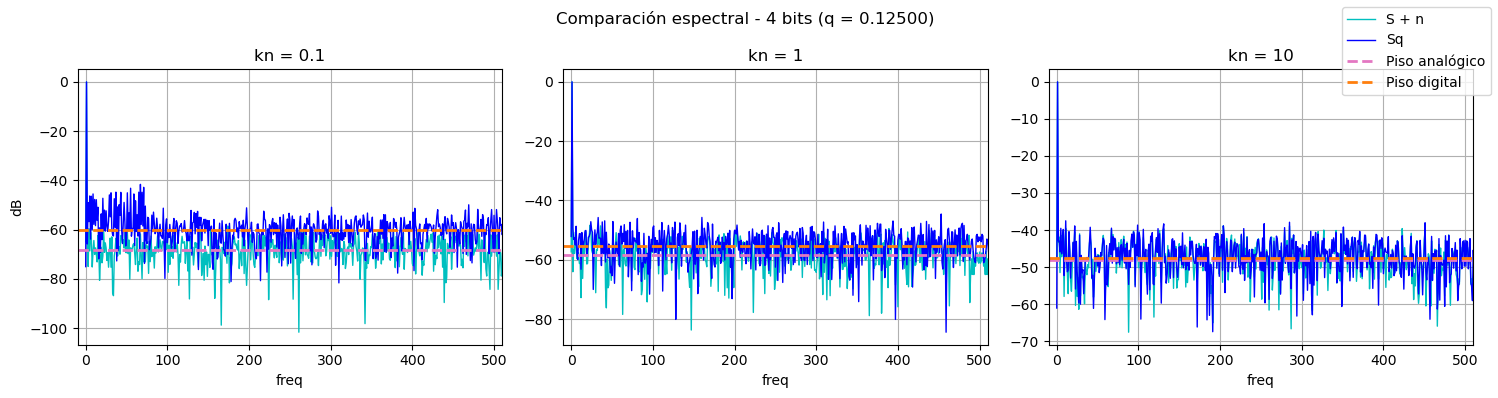

 Diferencia de pisos (kn =0.1) = 9.177858164406501 
 Diferencia de pisos (kn =1) = 2.931357093847822 
 Diferencia de pisos (kn =10) = 0.2462782204712255 


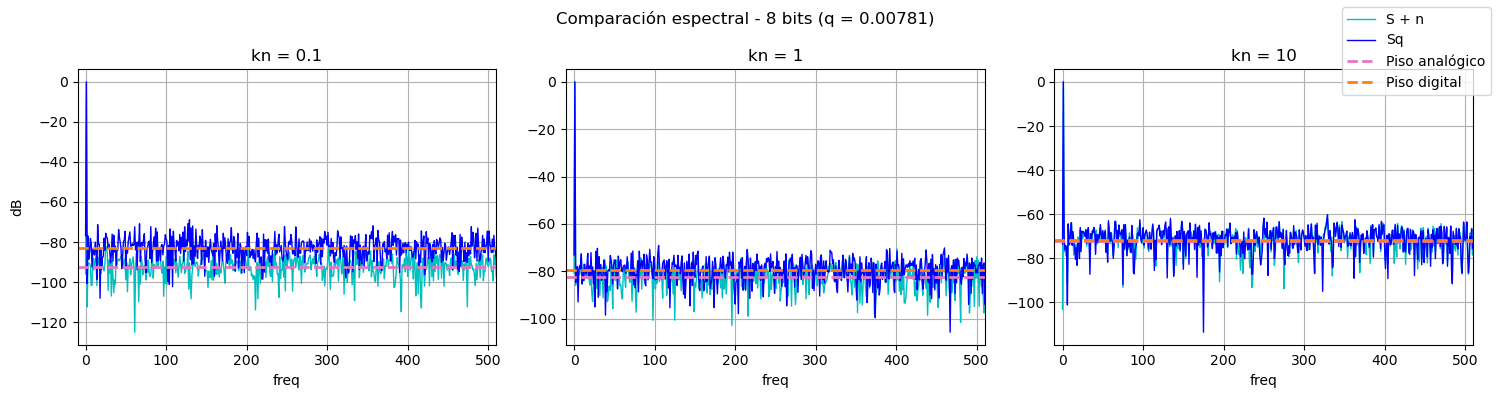

 Diferencia de pisos (kn =0.1) = 8.468735037959306 
 Diferencia de pisos (kn =1) = 2.851745194226183 
 Diferencia de pisos (kn =10) = 0.4216020269571885 


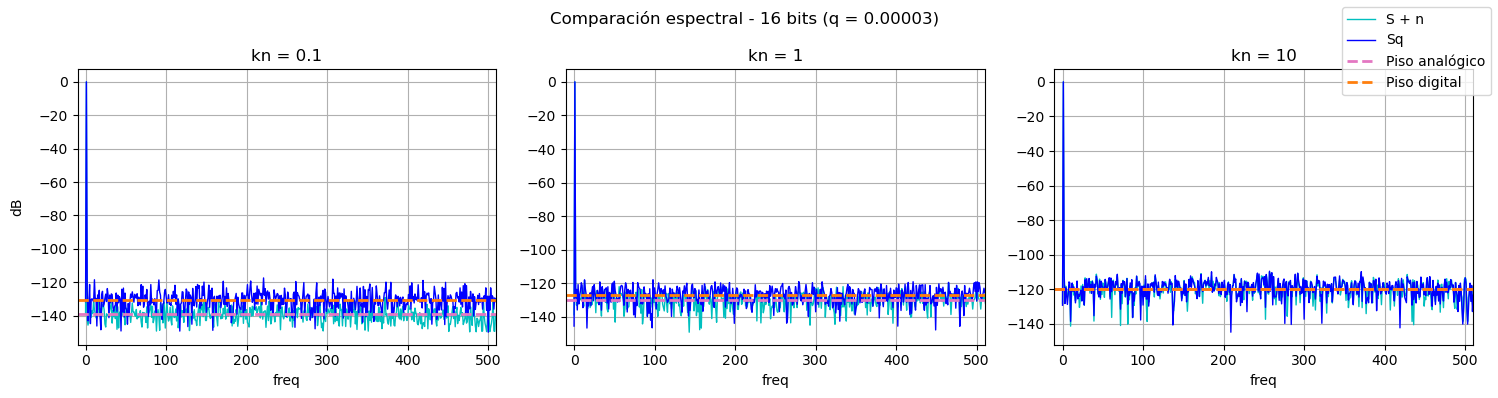

In [108]:
bits_list = [4, 8, 16]
kn_list = [0.1, 1, 10]

for bits in bits_list:
    
    q = Vf / (2**bits)
    Pq = (q**2)/12
    
    fig, axs = plt.subplots(1, len(kn_list), figsize=(15, 4))
    
    for j, kn in enumerate(kn_list):
        
        Pr = Pq * kn
        
        ax = axs[j]   
        
        # --- señales ---
        tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)
        n = mi_funcion_ruido(tt, Pr)
        Sn = S + n
        
        # cuantización
        Sq = q * np.round(Sn/q)
        
        # FFT
        e_Sr = np.fft.fft(Sn)/(muestras)  
        mod_e_Sr = 2*np.abs(e_Sr)**2
        
        e_Sq = np.fft.fft(Sq)/(muestras)
        mod_e_Sq = 2*np.abs(e_Sq)**2
        
        # dB
        mod_e_Sr_db = 10*np.log10(mod_e_Sr + 1e-15)
        mod_e_Sq_db = 10*np.log10(mod_e_Sq + 1e-15)
        
        # pisos
        piso_analog = np.mean(mod_e_Sr_db)
        piso_digital = np.mean(mod_e_Sq_db)

        
        ffreq = np.arange(muestras)
        
        # --- TU GRÁFICO ORIGINAL ---
        ax.plot(ffreq, mod_e_Sr_db, 'c', label="S + n", linewidth=1)
        ax.plot(ffreq, mod_e_Sq_db, 'b', label="Sq", linewidth=1)
        
        ax.axhline(piso_analog, color='C6',
                   linestyle='--', linewidth=2,
                   label="Piso analógico")
        
        ax.axhline(piso_digital, color='C1',
                   linestyle='--', linewidth=2,
                   label="Piso digital")
        
        ax.set_title(f"kn = {kn}")
        ax.set_xlim(-10, 510)
        ax.grid(True)
        
        if j == 0:
            ax.set_ylabel("dB")
        
        ax.set_xlabel("freq")
        print(f" Diferencia de pisos (kn ={kn_list[j]}) = {piso_digital -piso_analog} ")
       
    # título general de la figura
    fig.suptitle(f"Comparación espectral - {bits} bits (q = {q:.5f})")
    
    # leyenda (solo una vez)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()

    plt.show()

## Conclusión

A partir de los gráficos se puede ver cómo influyen tanto la cantidad de bits del ADC como la relación entre el ruido analógico y el de cuantización.

En este trabajo se definió $P_n = k_n P_q$ , es decir, el ruido analógico es proporcional al de cuantización. Esto hace que al variar $k_n$ no se obtenga directamente una diferencia en dB igual a $10\log_{10}(k_n)$ , porque el piso total siempre es la suma de ambos ruidos.

En particular, para $k_n = 10$, el ruido analógico domina ($P_n = 10P_q$), y la diferencia entre el piso digital y el analógico resulta:

$$
10\log_{10}\left(\frac{P_q + 10P_q}{10P_q}\right) = 10\log_{10}(1.1) \approx 0.4 \text{ dB}
$$

Por el contrario, para $k_n = 0.1$, el ruido de cuantización es predominante, y la diferencia de pisos se aproxima a:

$$
10\log_{10}\left(\frac{P_n + 10P_n}{P_n}\right) = 10\log_{10}(11) \approx 10.4 \text{ dB}
$$


Por otro lado, al aumentar la cantidad de bits, disminuye el paso de cuantización $q$ y por lo tanto también $P_q$. Pero como en este modelo el ruido analógico depende de $P_q$ , ambos ruidos bajan al mismo tiempo. Esto se ve en los gráficos: los pisos bajan en todos los casos, pero la relación entre ellos se mantiene.

Esto es importante porque muestra que en esta simulación aumentar los bits no mejora realmente la relación señal-ruido, sino que simplemente baja todo el nivel de ruido. En un caso más realista, donde el ruido analógico no depende de $P_q$, sí se vería una mejora clara al aumentar la resolución.

En definitiva, el parámetro $k_n$ define qué ruido domina. Si es pequeño, domina la cuantización y aumentar los bits mejora mucho el resultado. Si es grande, domina el ruido analógico y aumentar los bits ya no aporta una mejora significativa.

Por lo tanto, aumentar la resolución del ADC solo tiene sentido cuando el problema principal es la cuantización, en caso contario , conviene concentrarse  en una mejora del lado analógico.